# Module 3 — Measuring Relationships: Correlation (and its traps)
### Practical Statistics for Analysts @ Natural Intelligence

"EPV varies by day of week." Maybe — but **correlation is a hypothesis, not a finding.**
Two traps bite NI analysts constantly:
1. **Outliers distort Pearson** correlation → rank-based (Spearman/Kendall) is safer on EPV.
2. **A confound fakes a relationship** → the day-of-week "effect" is really a *traffic-mix* effect.

In [1]:
import sys
from pathlib import Path
_here = Path.cwd()
for _c in [_here, *_here.parents]:
    if (_c / "src" / "ni_style.py").exists():
        sys.path.insert(0, str(_c / "src")); break
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import ni_style as ni
ni.set_style()

visits = ni.load_visits()
print(f"Loaded {len(visits):,} visits | {visits['date'].min().date()} -> {visits['date'].max().date()}")
visits.head()

Loaded 180,000 visits | 2026-03-01 -> 2026-05-30


,visit_id,date,day_of_week,is_weekend,engine,device,vertical,converted,revenue,cost,profit
0,1,2026-03-01,Sun,True,Bing,mobile,vpn,0,0.0000,0.8094,-0.8094
1,2,2026-03-01,Sun,True,Organic,tablet,vpn,0,0.0000,0.1886,-0.1886
2,3,2026-03-01,Sun,True,Google,tablet,web_builders,0,0.0000,3.6039,-3.6039
3,4,2026-03-01,Sun,True,Google,desktop,dating,1,10.0945,1.0836,9.0109
4,5,2026-03-01,Sun,True,Google,desktop,streaming,1,5.6453,0.8228,4.8225


In [2]:
# Daily aggregates we'll relate to each other
daily = visits.groupby("date", observed=True).agg(
    EPV=("revenue","mean"), CPV=("cost","mean"),
    conv=("converted","mean"), visits=("visit_id","size")).reset_index()
daily["dow_idx"] = daily["date"].dt.dayofweek           # 0=Mon..6=Sun
daily["dow"] = pd.Categorical(daily["date"].dt.strftime("%a"), categories=ni.DOW_ORDER, ordered=True)
daily.head()

,date,EPV,CPV,conv,visits,dow_idx,dow
0,2026-03-01,5.127160,2.242977,0.390046,1969,6,Sun
1,2026-03-02,10.688057,4.948692,0.417728,1884,0,Mon
2,2026-03-03,10.286343,4.817064,0.397547,1957,1,Tue
3,2026-03-04,9.109589,4.554038,0.400888,2028,2,Wed
4,2026-03-05,7.885399,4.964065,0.388409,1967,3,Thu


## 1. The raw picture: EPV by day of week

There *is* a striking weekly pattern — weekdays look far richer than weekends.

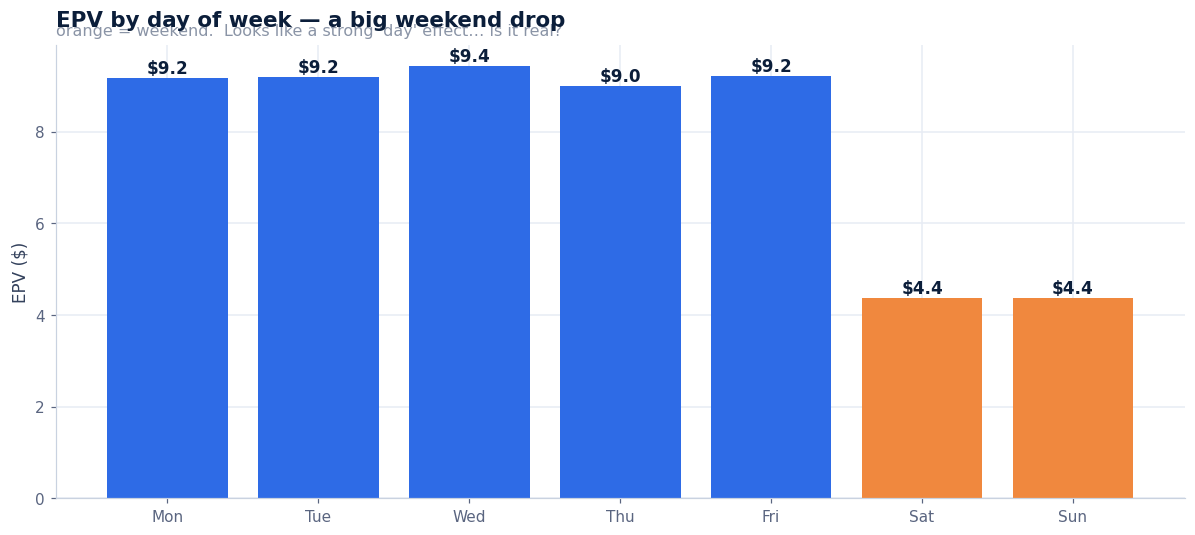

In [3]:
by_dow = visits.groupby("day_of_week", observed=True)["revenue"].mean().reindex(ni.DOW_ORDER)
fig, ax = plt.subplots(figsize=(11, 5))
colors = [ni.BLUE if d not in ("Sat","Sun") else ni.ORANGE for d in by_dow.index]
ax.bar(by_dow.index, by_dow.values, color=colors)
for i, v in enumerate(by_dow.values):
    ax.text(i, v+0.1, f"${v:.1f}", ha="center", fontweight="bold", color=ni.NAVY)
ax.set_ylabel("EPV ($)")
ni.titlebox(ax, "EPV by day of week — a big weekend drop",
            "orange = weekend.  Looks like a strong 'day' effect… is it real?")
fig.tight_layout(); ni.savefig(fig, "m3_epv_by_dow"); plt.show()

## 2. Three correlation coefficients — and why Pearson can mislead

**Pearson** measures *linear* association and is sensitive to outliers.
**Spearman** and **Kendall** work on *ranks* — robust to skew and whales.
On NI metrics, **default to Spearman.**

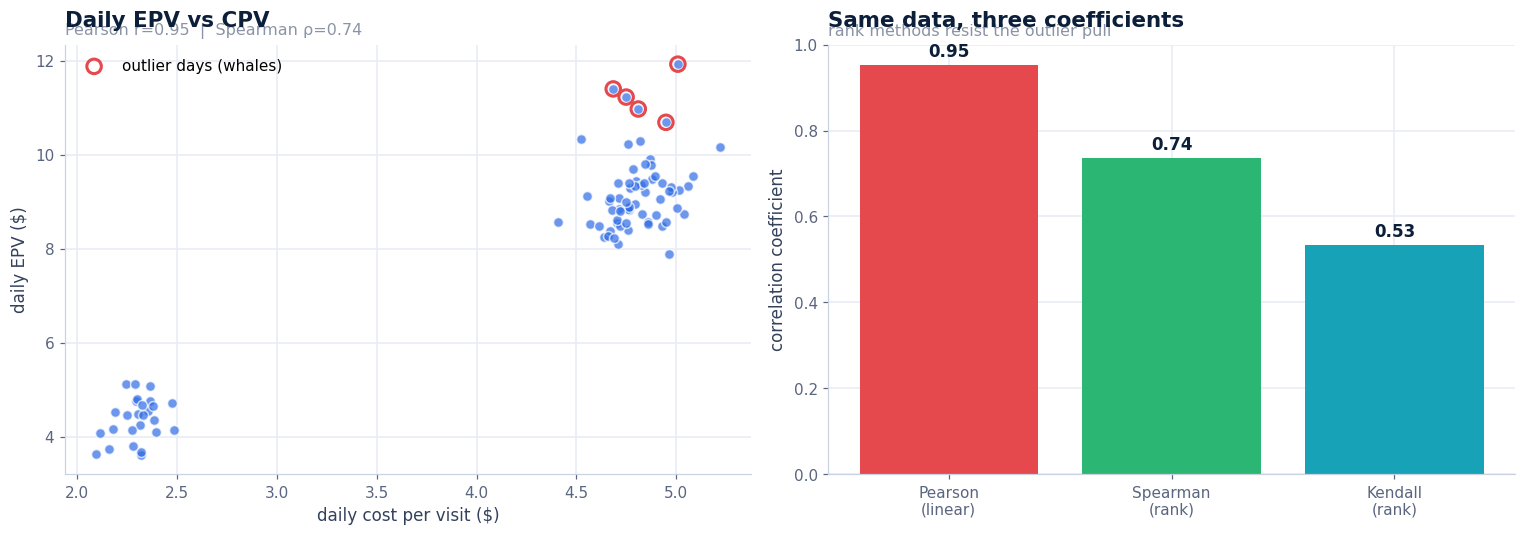

In [4]:
# Relate daily EPV to daily cost — outlier days make Pearson and Spearman disagree
x, y = daily["CPV"].values, daily["EPV"].values
pear = stats.pearsonr(x, y); spear = stats.spearmanr(x, y); kend = stats.kendalltau(x, y)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].scatter(x, y, s=42, color=ni.BLUE, alpha=0.7, edgecolor="white")
# highlight whale-driven outlier days
hi = y > np.percentile(y, 95)
ax[0].scatter(x[hi], y[hi], s=90, facecolor="none", edgecolor=ni.RED, linewidth=2, label="outlier days (whales)")
ax[0].set_xlabel("daily cost per visit ($)"); ax[0].set_ylabel("daily EPV ($)"); ax[0].legend()
ni.titlebox(ax[0], "Daily EPV vs CPV",
            f"Pearson r={pear.statistic:.2f}  |  Spearman ρ={spear.statistic:.2f}")

methods = ["Pearson\n(linear)", "Spearman\n(rank)", "Kendall\n(rank)"]
vals = [pear.statistic, spear.statistic, kend.statistic]
ax[1].bar(methods, vals, color=[ni.RED, ni.GREEN, ni.TEAL])
for i, v in enumerate(vals):
    ax[1].text(i, v+0.02, f"{v:.2f}", ha="center", fontweight="bold", color=ni.NAVY)
ax[1].set_ylabel("correlation coefficient"); ax[1].set_ylim(0, 1)
ni.titlebox(ax[1], "Same data, three coefficients", "rank methods resist the outlier pull")
fig.tight_layout(); ni.savefig(fig, "m3_three_correlations"); plt.show()

### Outliers really do move Pearson

Remove just the top-5% whale days and watch **Pearson jump while Spearman barely
budges** — proof that the rank measure is telling you the stable story.

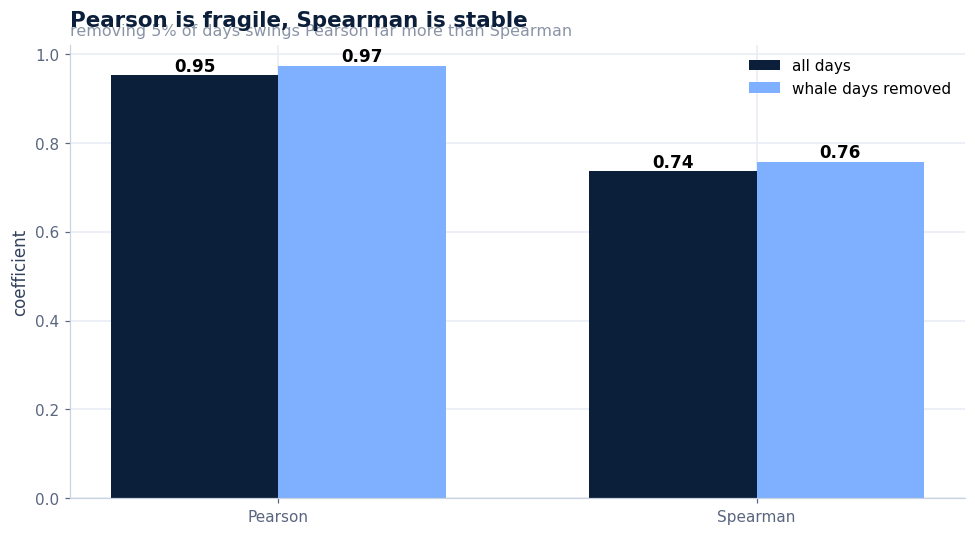

In [5]:
keep = ~hi
p_all, p_trim = stats.pearsonr(x, y).statistic, stats.pearsonr(x[keep], y[keep]).statistic
s_all, s_trim = stats.spearmanr(x, y).statistic, stats.spearmanr(x[keep], y[keep]).statistic

fig, ax = plt.subplots(figsize=(9, 5))
xb = np.arange(2); w = 0.35
ax.bar(xb-w/2, [p_all, s_all], w, label="all days", color=ni.NAVY)
ax.bar(xb+w/2, [p_trim, s_trim], w, label="whale days removed", color=ni.SKY)
ax.set_xticks(xb); ax.set_xticklabels(["Pearson", "Spearman"]); ax.set_ylabel("coefficient"); ax.legend()
for i,(a,b) in enumerate([(p_all,p_trim),(s_all,s_trim)]):
    ax.text(i-w/2, a+0.01, f"{a:.2f}", ha="center", fontweight="bold")
    ax.text(i+w/2, b+0.01, f"{b:.2f}", ha="center", fontweight="bold")
ni.titlebox(ax, "Pearson is fragile, Spearman is stable",
            "removing 5% of days swings Pearson far more than Spearman")
fig.tight_layout(); ni.savefig(fig, "m3_pearson_fragile"); plt.show()

## 3. The confound: it was never about the *day*

The weekend EPV drop is real in the raw data — but it's driven by **what kind of
traffic runs on weekends**, not the day itself. NI sends more high-payout finance
traffic on weekdays and more entertainment traffic on weekends. **Control for
vertical and the day effect collapses.**

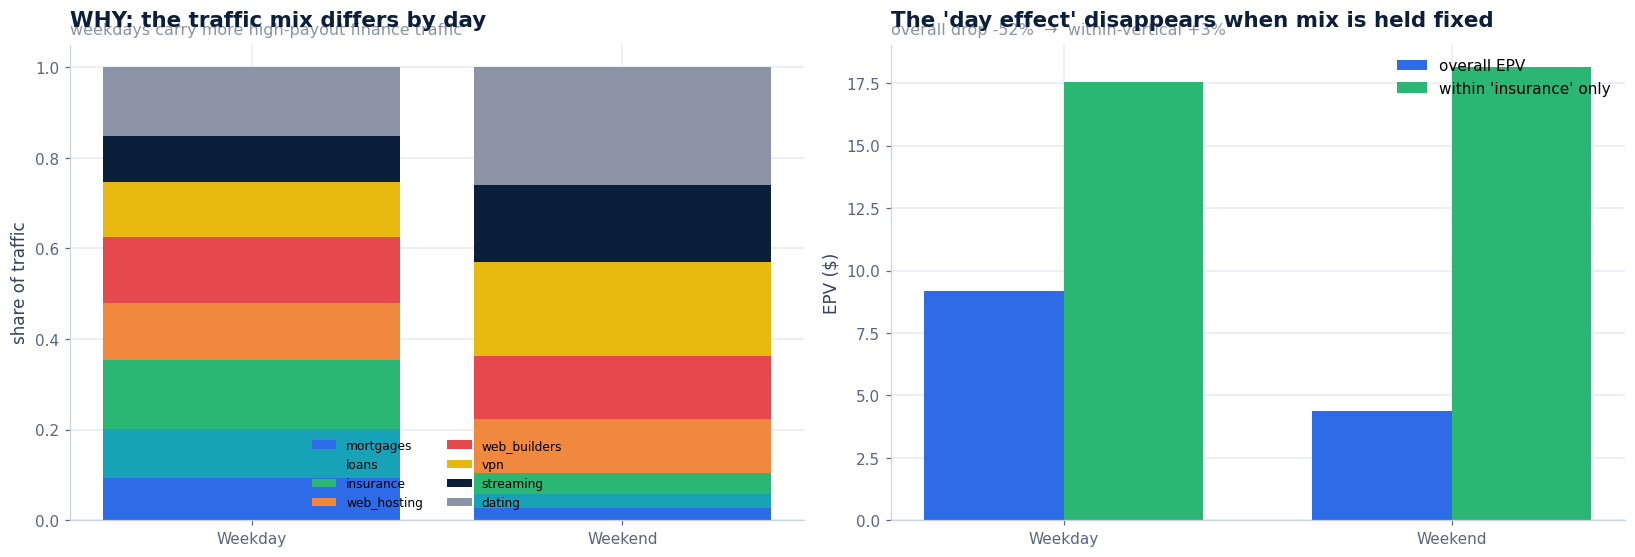

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5.2))

# Left: weekday vertical MIX vs weekend — the real driver
mix = (visits.assign(part=np.where(visits.is_weekend,"Weekend","Weekday"))
       .pivot_table(index="part", columns="vertical", values="visit_id", aggfunc="size"))
mix = mix.div(mix.sum(axis=1), axis=0)[
    ["mortgages","loans","insurance","web_hosting","web_builders","vpn","streaming","dating"]]
bottom = np.zeros(len(mix))
for i, v in enumerate(mix.columns):
    ax[0].bar(mix.index, mix[v], bottom=bottom, label=v, color=ni.SEQ[i % len(ni.SEQ)])
    bottom += mix[v].values
ax[0].set_ylabel("share of traffic"); ax[0].legend(ncol=2, fontsize=8, loc="lower center")
ni.titlebox(ax[0], "WHY: the traffic mix differs by day",
            "weekdays carry more high-payout finance traffic")

# Right: EPV by weekend overall vs WITHIN one vertical (insurance)
parts = ["Weekday","Weekend"]
overall = [visits.loc[~visits.is_weekend,"revenue"].mean(), visits.loc[visits.is_weekend,"revenue"].mean()]
ins = visits[visits.vertical=="insurance"]
within = [ins.loc[~ins.is_weekend,"revenue"].mean(), ins.loc[ins.is_weekend,"revenue"].mean()]
xb = np.arange(2); w=0.36
ax[1].bar(xb-w/2, overall, w, label="overall EPV", color=ni.BLUE)
ax[1].bar(xb+w/2, within, w, label="within 'insurance' only", color=ni.GREEN)
ax[1].set_xticks(xb); ax[1].set_xticklabels(parts); ax[1].set_ylabel("EPV ($)"); ax[1].legend()
ni.titlebox(ax[1], "The 'day effect' disappears when mix is held fixed",
            f"overall drop {overall[1]/overall[0]-1:+.0%}  →  within-vertical {within[1]/within[0]-1:+.0%}")
fig.tight_layout(); ni.savefig(fig, "m3_confound"); plt.show()

### ✅ Takeaway

> **On NI data, default to Spearman, and treat every correlation as a *question*.**
> "EPV depends on the day of week" was a **mix artifact** — the day didn't cause
> anything; the *vertical composition* of weekend traffic did. Before acting on
> any correlation, ask: *what third variable changes alongside both of these?*

**Next:** the Slack message claims Google ≠ Bing on conversion. Is that gap real,
or could it be luck? → *Module 4.*